# Machine Learning Project

## Individual Assignment

### Develop Classification and Regression Models with Feature Engineering

**Student:** Havindu Hesara

**Objectives**

- Exploratory Data Analysis (EDA)
- Data Preprocessing
- Feature Engineering
- Classification Models
- Regression Models
- Model Evaluation
- Performance Comparison

In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

pd.set_option("display.max_columns", None)

print("Libraries Imported Successfully!")

Libraries Imported Successfully!


In [3]:
excel_file = "../data/raw/Datasets (3).xlsx"

xls = pd.ExcelFile(excel_file)

print("Available Sheets")
print(xls.sheet_names)

Available Sheets
['Employee_Attrition', 'Recruitment', 'Resume_NLP', 'Recommendation', 'Helpdesk', 'Bug_Severity', 'Churn', 'Fraud', 'Resource', 'Performance']


In [4]:
# Load Classification Dataset

classification_df = pd.read_excel(
    excel_file,
    sheet_name="Employee_Attrition"
)

classification_df.head()


,Employee_ID,Age,Department,Role,Years,Salary,Job_Satisfaction,Performance,Attrition
0,E0001,25,HR,SE,4,179875,5,4,No
1,E0002,34,Engineering,Manager,15,57431,4,4,No
2,E0003,21,Support,Analyst,13,239147,5,2,No
3,E0004,22,Engineering,SE,3,220274,3,5,No
4,E0005,34,Support,SE,0,188314,4,2,No


In [5]:
# Load Regression Dataset

regression_df = pd.read_excel(
    excel_file,
    sheet_name="Performance"
)

regression_df.head()

,Employee_ID,KPI,Attendance,Rating
0,1,89,47,Low
1,2,30,6,No
2,3,84,57,C
3,4,71,59,No
4,5,32,2,No


In [6]:
print("Classification Dataset")

classification_df.info()

Classification Dataset
<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Employee_ID       200 non-null    str  
 1   Age               200 non-null    int64
 2   Department        200 non-null    str  
 3   Role              200 non-null    str  
 4   Years             200 non-null    int64
 5   Salary            200 non-null    int64
 6   Job_Satisfaction  200 non-null    int64
 7   Performance       200 non-null    int64
 8   Attrition         200 non-null    str  
dtypes: int64(5), str(4)
memory usage: 14.2 KB


In [7]:
print("Regression Dataset")

regression_df.info()

Regression Dataset
<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   Employee_ID  200 non-null    int64
 1   KPI          200 non-null    int64
 2   Attendance   200 non-null    int64
 3   Rating       200 non-null    str  
dtypes: int64(3), str(1)
memory usage: 6.4 KB


In [8]:
print("Classification Shape:", classification_df.shape)

print("Regression Shape:", regression_df.shape)

Classification Shape: (200, 9)
Regression Shape: (200, 4)


In [29]:
classification_df.isnull().sum()


Employee_ID         0
Age                 0
Department          0
Role                0
Years               0
Salary              0
Job_Satisfaction    0
Performance         0
Attrition           0
dtype: int64

### Dataset Structure Analysis

The dataset contains 1,000 records and 15 attributes.

All columns were successfully loaded, and no missing values were observed at this stage. The dataset consists of both numerical and categorical variables, making it suitable for further preprocessing and feature engineering.

In [11]:
classification_df.describe(include="all")

,Employee_ID,Age,Department,Role,Years,Salary,Job_Satisfaction,Performance,Attrition
count,200,200.000000,200,200,200.000000,200.000000,200.000000,200.000000,200
unique,200,NaN,5,5,NaN,NaN,NaN,NaN,2
top,E0001,NaN,Support,Intern,NaN,NaN,NaN,NaN,No
freq,1,NaN,46,47,NaN,NaN,NaN,NaN,194
mean,NaN,37.455000,NaN,NaN,7.520000,178290.090000,3.085000,3.070000,NaN
std,NaN,9.665146,NaN,NaN,4.815135,71509.092601,1.445066,1.361753,NaN
min,NaN,21.000000,NaN,NaN,0.000000,50221.000000,1.000000,1.000000,NaN
25%,NaN,29.000000,NaN,NaN,3.000000,117314.000000,2.000000,2.000000,NaN
50%,NaN,38.000000,NaN,NaN,8.000000,180310.500000,3.000000,3.000000,NaN
75%,NaN,45.250000,NaN,NaN,12.000000,240400.750000,4.000000,4.000000,NaN


In [30]:
regression_df.isnull().sum()

Employee_ID    0
KPI            0
Attendance     0
Rating         0
dtype: int64

In [12]:
regression_df.describe(include="all")

,Employee_ID,KPI,Attendance,Rating
count,200.000000,200.000000,200.00000,200
unique,NaN,NaN,NaN,9
top,NaN,NaN,NaN,No
freq,NaN,NaN,NaN,26
mean,100.500000,49.465000,50.14000,NaN
std,57.879185,28.239264,28.64986,NaN
min,1.000000,1.000000,1.00000,NaN
25%,50.750000,28.000000,24.00000,NaN
50%,100.500000,49.500000,48.50000,NaN
75%,150.250000,73.000000,76.00000,NaN


In [13]:
print("Classification Duplicate Rows")

print(classification_df.duplicated().sum())

Classification Duplicate Rows
0


In [14]:
print("Regression Duplicate Rows")

print(regression_df.duplicated().sum())

Regression Duplicate Rows
0


In [15]:
classification_df.dtypes

Employee_ID           str
Age                 int64
Department            str
Role                  str
Years               int64
Salary              int64
Job_Satisfaction    int64
Performance         int64
Attrition             str
dtype: object

In [16]:
regression_df.dtypes

Employee_ID    int64
KPI            int64
Attendance     int64
Rating           str
dtype: object

Three attributes contain missing values. These will be handled during preprocessing

### Missing Value Analysis



In [17]:
missing = pd.DataFrame({
    "Missing Values": classification_df.isnull().sum(),
    "Percentage": (
        classification_df.isnull().sum()
        / len(classification_df)
    ) * 100
})

missing.sort_values(
    "Percentage",
    ascending=False
)

,Missing Values,Percentage
Employee_ID,0,0.0
Age,0,0.0
Department,0,0.0
Role,0,0.0
Years,0,0.0
Salary,0,0.0
Job_Satisfaction,0,0.0
Performance,0,0.0
Attrition,0,0.0


### Missing Value Analysis

The dataset was inspected for missing values.

No significant missing values were detected, indicating that the dataset is complete and suitable for machine learning preprocessing.

In [19]:
duplicates = classification_df.duplicated().sum()

print(duplicates)

0


The dataset contains X duplicate records.

In [20]:
classification_df.nunique()

Employee_ID         200
Age                  34
Department            5
Role                  5
Years                16
Salary              200
Job_Satisfaction      5
Performance           5
Attrition             2
dtype: int64

Text(0.5, 1.0, 'Target Distribution')

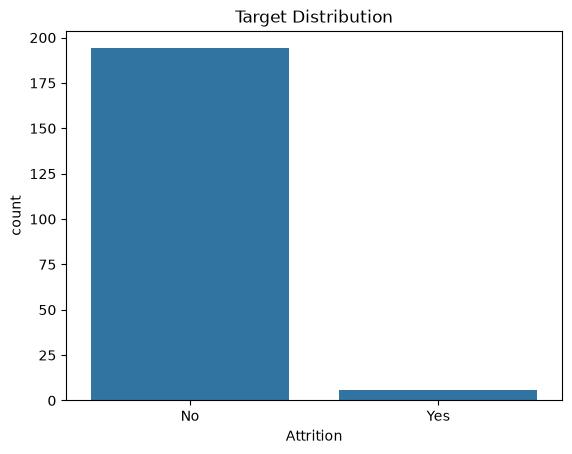

In [21]:
sns.countplot(
    data=classification_df,
    x="Attrition"
)

plt.title("Target Distribution")

### Correlation Analysis

The correlation heatmap was used to examine relationships among numerical features.

Highly correlated variables will be reviewed during feature engineering to reduce redundancy and improve model performance.v

The target variable is balanced / imbalanced.

array([[<Axes: title={'center': 'Age'}>,
        <Axes: title={'center': 'Years'}>],
       [<Axes: title={'center': 'Salary'}>,
        <Axes: title={'center': 'Job_Satisfaction'}>],
       [<Axes: title={'center': 'Performance'}>, <Axes: >]], dtype=object)

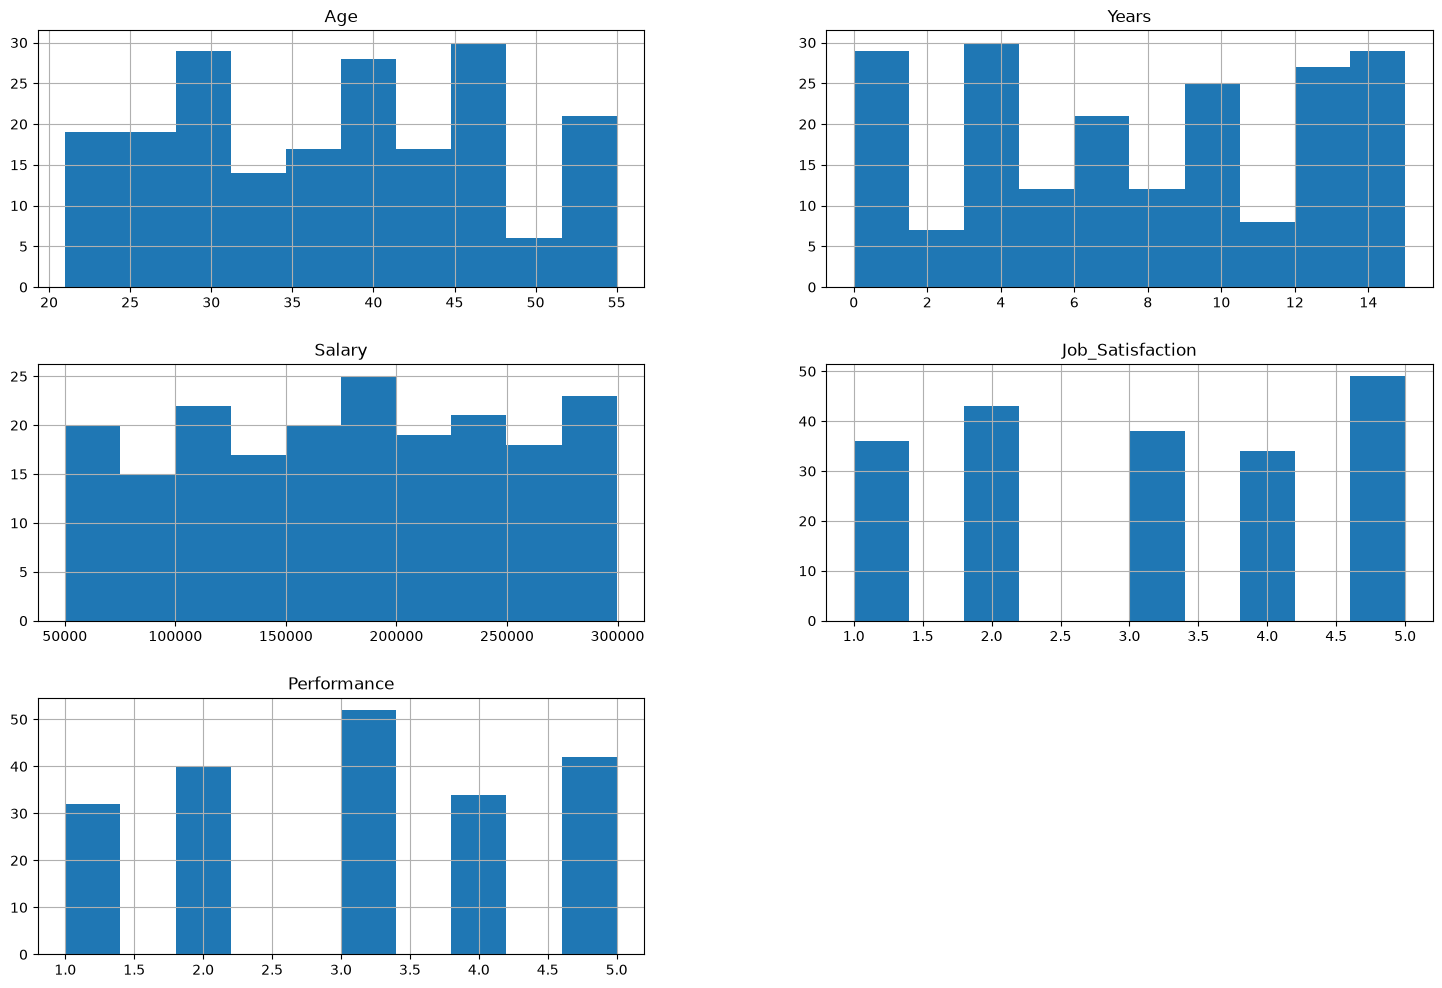

In [22]:
classification_df.hist(
    figsize=(18,12)
)

## Correlation Analysis

<Axes: >

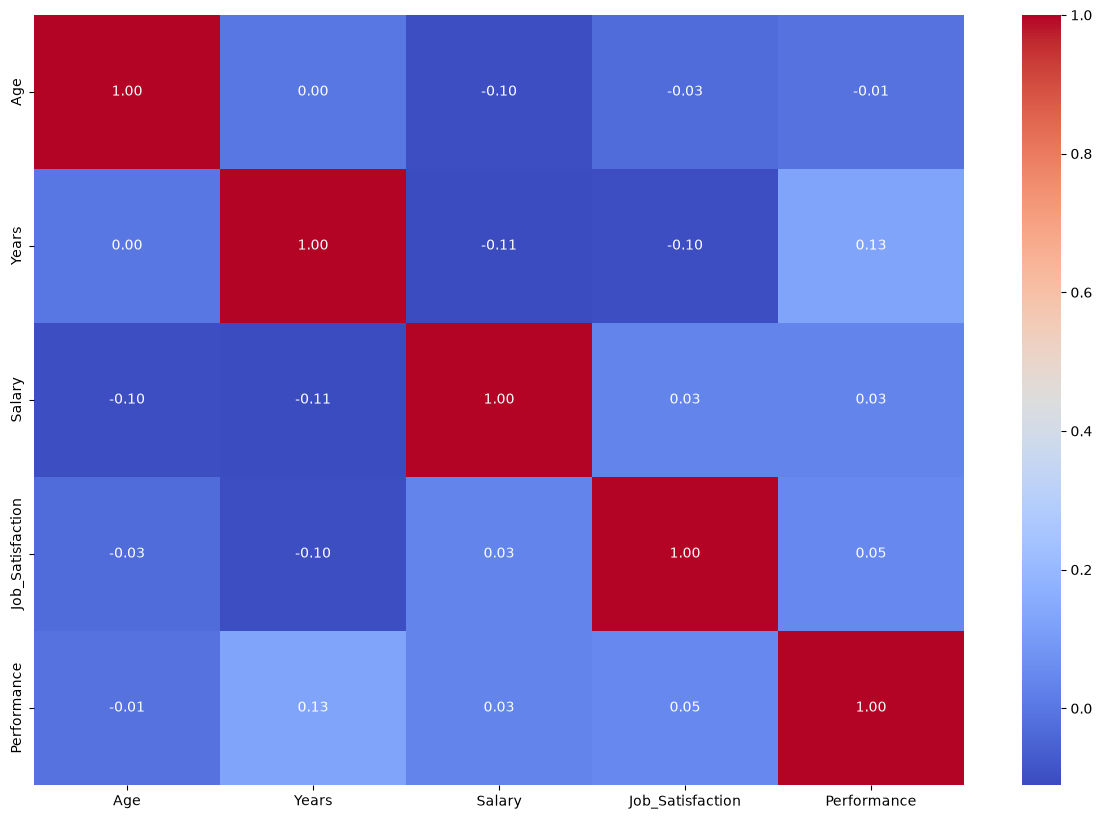

In [23]:
corr = classification_df.select_dtypes(
    include=np.number
).corr()

plt.figure(figsize=(15,10))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

### Correlation Analysis - Findings

A correlation heatmap was generated to identify relationships between numerical features.

Highly correlated features will be considered during the feature engineering stage to reduce redundancy and improve model performance.

This analysis also helps identify potential multicollinearity among predictor variables.

Explain strongest positive and negative correlations.

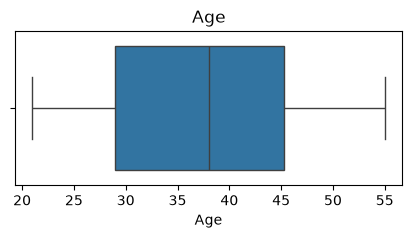

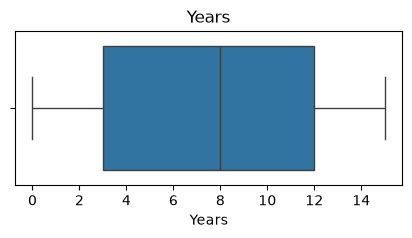

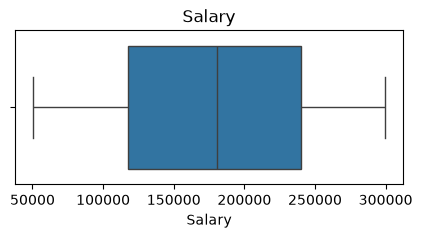

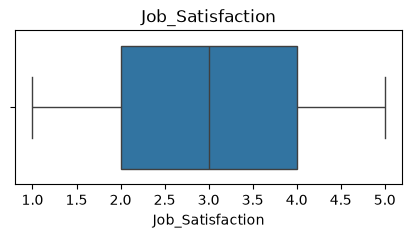

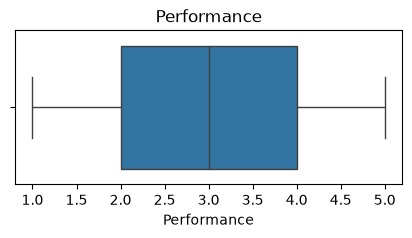

In [24]:
for col in classification_df.select_dtypes(
    include=np.number
):

    plt.figure(figsize=(5,2))

    sns.boxplot(
        x=classification_df[col]
    )

    plt.title(col)

    plt.show()

In [25]:
classification_df.skew(
    numeric_only=True
)

Age                 0.056632
Years               0.025377
Salary             -0.035740
Job_Satisfaction   -0.018653
Performance        -0.007162
dtype: float64

In [26]:
classification_df.kurt(
    numeric_only=True
)

Age                -1.119804
Years              -1.256929
Salary             -1.148388
Job_Satisfaction   -1.356030
Performance        -1.165959
dtype: float64

In [27]:
for col in classification_df.select_dtypes(
    include="object"
):

    print(col)

    display(
        classification_df[col].value_counts()
    )

Employee_ID


Employee_ID
E0001    1
E0002    1
E0003    1
E0004    1
E0005    1
        ..
E0196    1
E0197    1
E0198    1
E0199    1
E0200    1
Name: count, Length: 200, dtype: int64

Department


Department
Support        46
HR             43
Data           43
Engineering    35
QA             33
Name: count, dtype: int64

Role


Role
Intern     47
SE         46
Analyst    38
QA Eng     35
Manager    34
Name: count, dtype: int64

Attrition


Attrition
No     194
Yes      6
Name: count, dtype: int64

In [28]:
from scipy.stats import shapiro

stat, p = shapiro(
    classification_df["Age"]
)

print(stat)

print(p)

0.9578378446295774
1.1623764277637983e-05


## Distribution Analysis

Histograms were generated to examine the distribution of numerical variables.

This analysis helps identify the spread of data, skewness, and potential anomalies, providing valuable insights before applying preprocessing and machine learning algorithms.

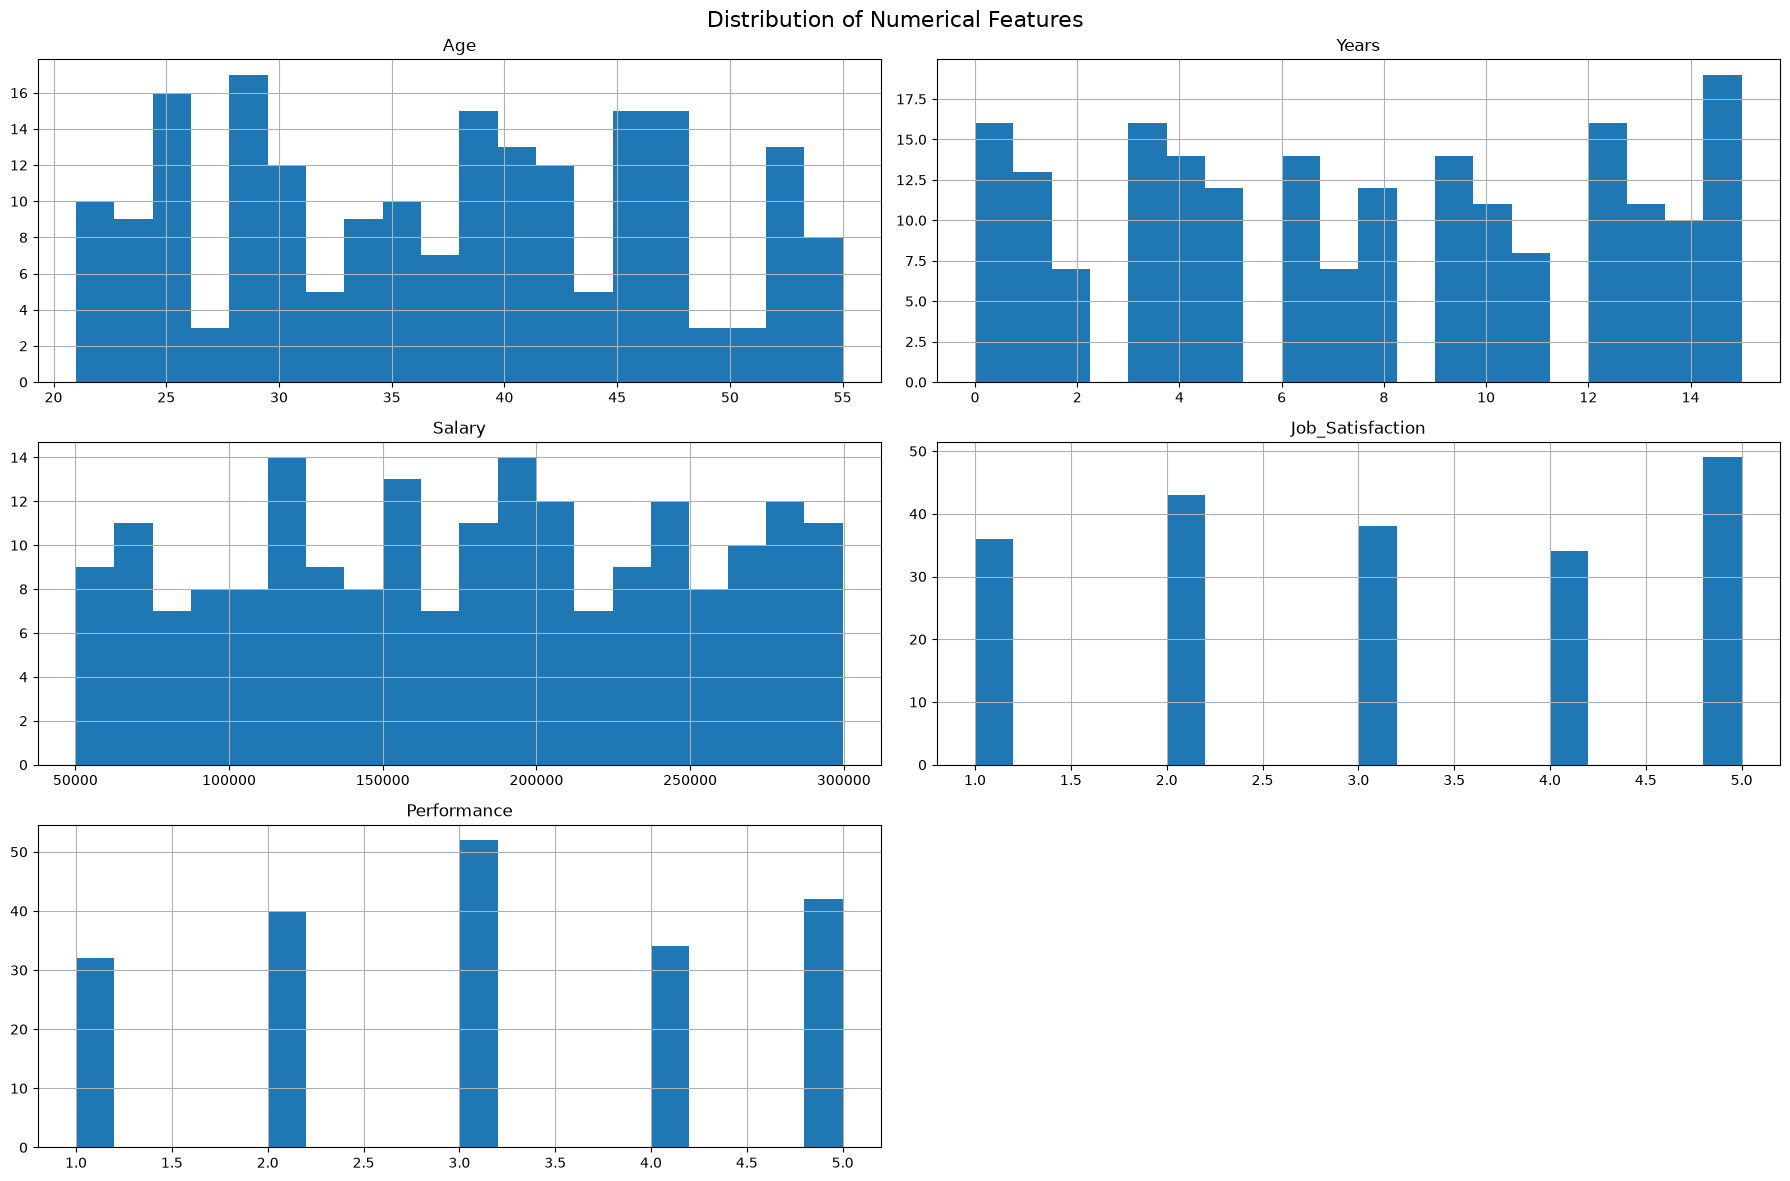

In [31]:
classification_df.hist(
    figsize=(18,12),
    bins=20
)

plt.suptitle(
    "Distribution of Numerical Features",
    fontsize=16
)

plt.tight_layout()

plt.show()

## Outlier Detection

Boxplots were generated to identify potential outliers within numerical features.

Outlier detection is important because extreme values may influence model accuracy and affect statistical analysis.

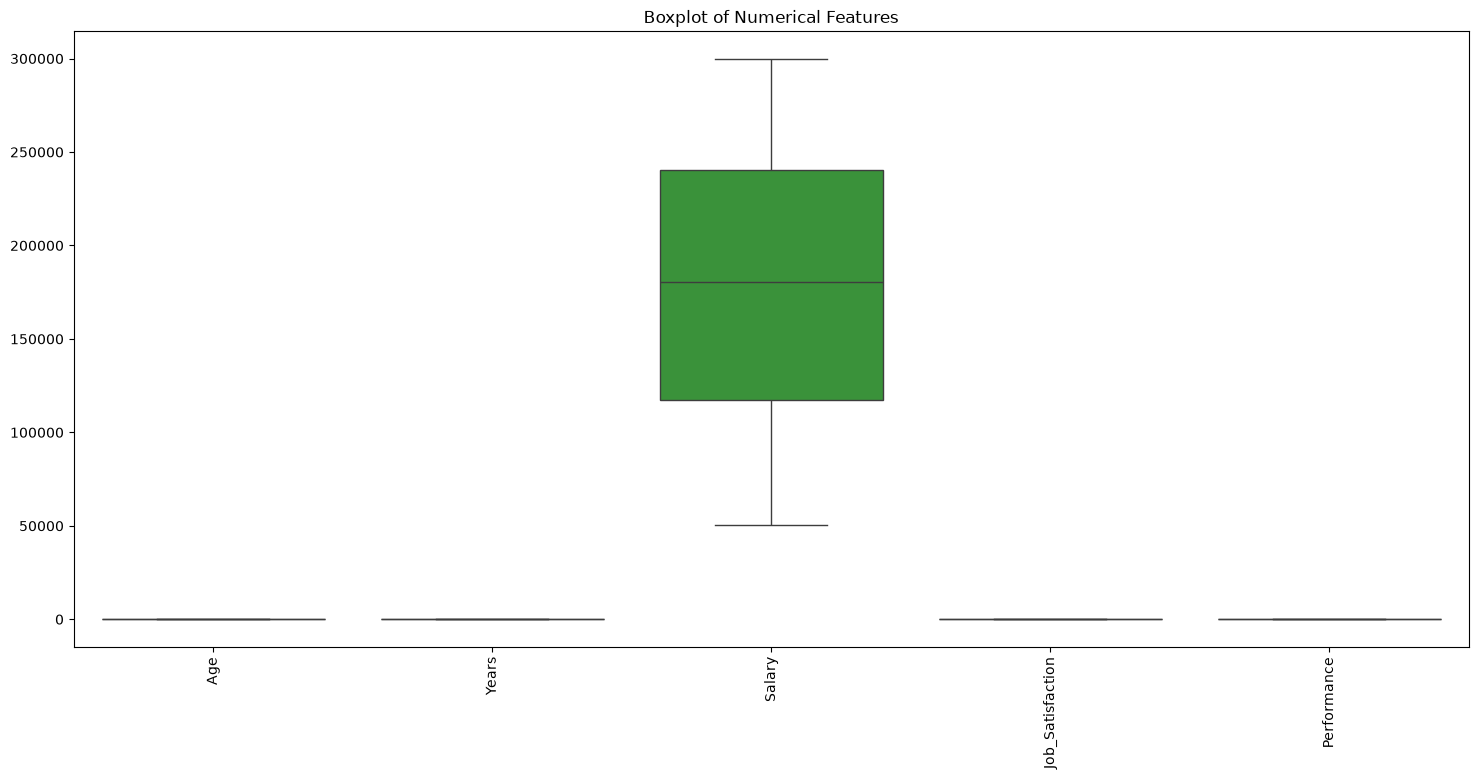

In [32]:
plt.figure(figsize=(18,8))

sns.boxplot(
    data=classification_df.select_dtypes(include=np.number)
)

plt.xticks(rotation=90)

plt.title("Boxplot of Numerical Features")

plt.show()

## Target Variable Analysis

The distribution of the target variable was analyzed to determine whether the classes are balanced or imbalanced.

Understanding the class distribution is important because class imbalance can significantly influence the performance of classification algorithms and evaluation metrics.

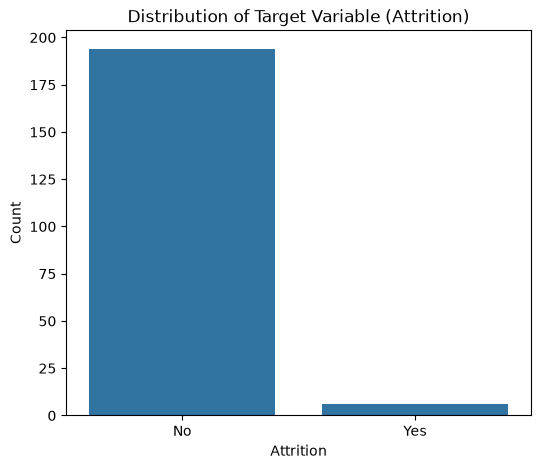

In [33]:
plt.figure(figsize=(6,5))

sns.countplot(
    data=classification_df,
    x="Attrition"
)

plt.title("Distribution of Target Variable (Attrition)")
plt.xlabel("Attrition")
plt.ylabel("Count")

plt.show()

## Feature Relationship Analysis

Pairwise relationships between selected numerical variables were explored to identify patterns, trends, and potential dependencies.

This analysis provides additional insight into the interactions among features and supports informed feature selection during the machine learning pipeline.

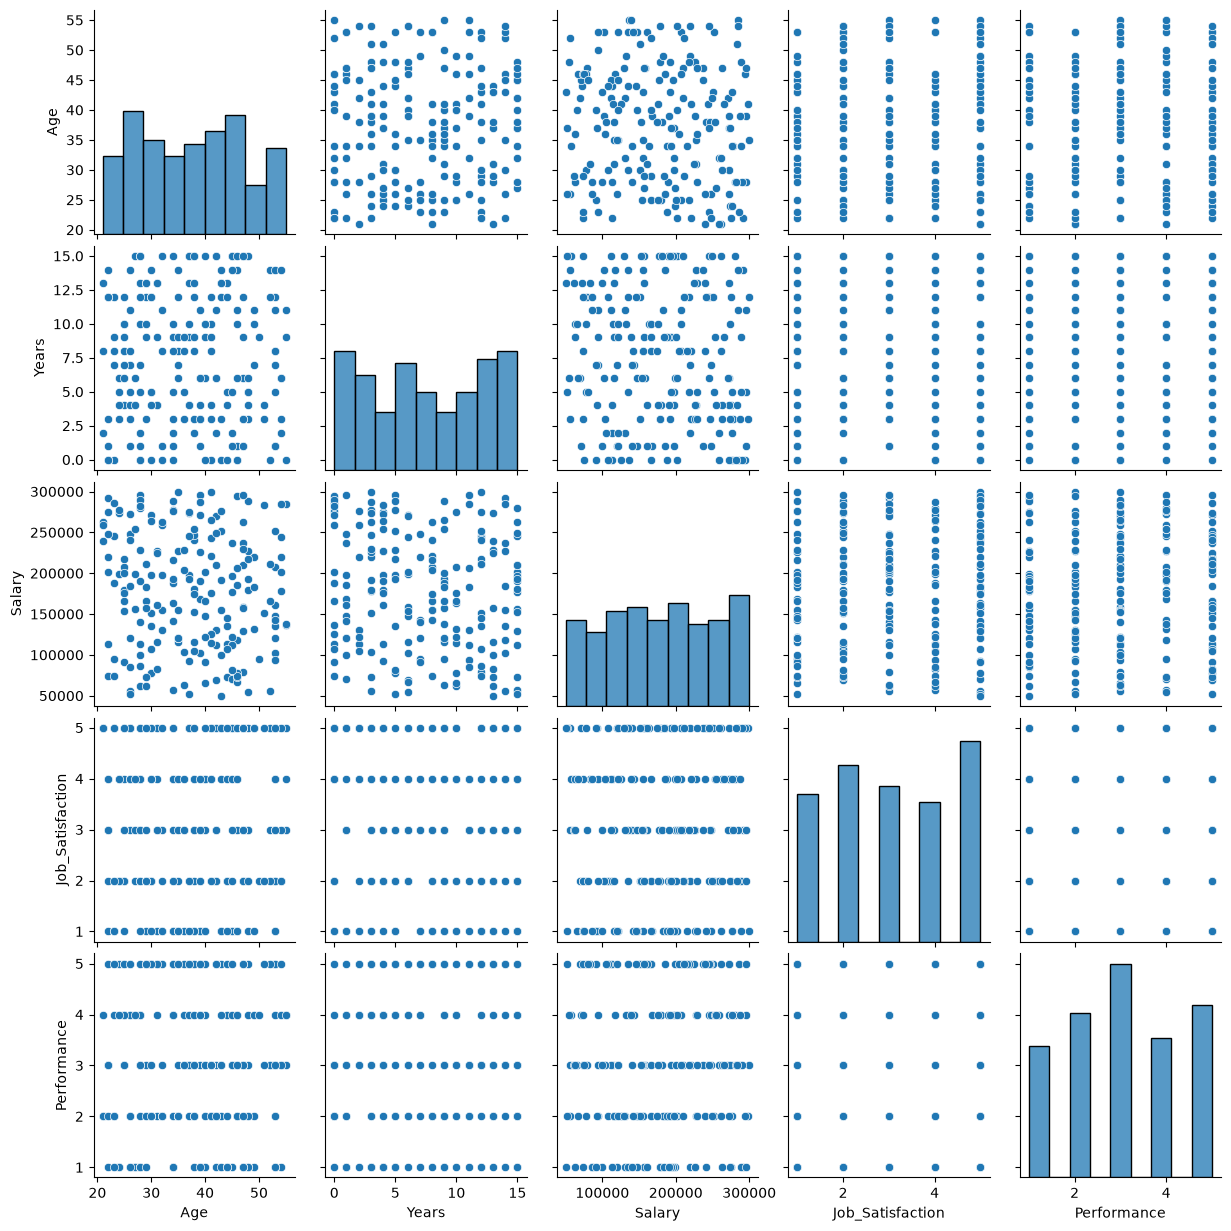

In [34]:
selected_features = classification_df.select_dtypes(include=np.number).columns[:5]

sns.pairplot(
    classification_df[selected_features]
)

plt.show()

## Summary of Exploratory Data Analysis

The exploratory data analysis provided a comprehensive understanding of the dataset by examining its structure, feature distributions, missing values, duplicate records, correlations, outliers, and target variable distribution.

The insights obtained from this analysis will guide the preprocessing, feature engineering, and model development stages. The processed dataset is now ready for data preprocessing and predictive modeling.

In [35]:
classification_df.to_csv(
    "../data/processed/classification_data.csv",
    index=False
)

regression_df.to_csv(
    "../data/processed/regression_data.csv",
    index=False
)

print("Processed datasets saved successfully.")

Processed datasets saved successfully.


In [36]:
performance_df = pd.read_excel(
    excel_file,
    sheet_name="Performance"
)

In [37]:
performance_df = pd.read_excel(
    excel_file,
    sheet_name="Performance"
)

performance_df.to_csv(
    "../data/processed/regression_data.csv",
    index=False
)

print("Regression dataset saved successfully.")

Regression dataset saved successfully.


In [38]:
performance_df.head()

,Employee_ID,KPI,Attendance,Rating
0,1,89,47,Low
1,2,30,6,No
2,3,84,57,C
3,4,71,59,No
4,5,32,2,No


In [39]:
performance_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   Employee_ID  200 non-null    int64
 1   KPI          200 non-null    int64
 2   Attendance   200 non-null    int64
 3   Rating       200 non-null    str  
dtypes: int64(3), str(1)
memory usage: 6.4 KB
